# CAB320 Assignment 2 - Transfer Learning
Anthony Vanderkop, Thierry Peynot, Frederic Maire (Jupyter Notebook template: 2025)


## Instructions:
The functions and classes defined in this module will be called by the marker without modification. 
You should complete the functions and classes according to their specified interfaces.

No partial marks will be awarded for functions that do not meet the specifications of the interfaces.


In [1]:
### LIBRARY IMPORTS ###
import os
import numpy as np
import keras.applications as ka
import keras
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score

## Task 1
Implement the my_team()function 

In [2]:
def my_team():
    '''
    Return the list of the team members of this assignment submission as a list
    of triplet of the form (student_number, first_name, last_name)
    
    '''
    return [(11885807, "Zach", "Coglan"), (12452068, "Xavier", "White") ]

In [3]:
# my_team()

## Task 2
Download the small_flower_dataset from Canvas and load the data

In [4]:
def load_data(path):
    '''
    Load in the dataset from its home path. Path should be a string of the path
    to the home directory the dataset is found in. Should return a numpy array
    with paired images and class labels.
    
    Insert a more detailed description here.
    '''
    # Using Keras Utils to load the given dataset
    dataset = keras.utils.image_dataset_from_directory(path, labels="inferred", label_mode="categorical", color_mode="rgb", batch_size=None)

    # Convert to numpy array
    dataset = dataset.as_numpy_iterator()
    dataset = np.fromiter(dataset, dtype="object")

    return dataset

In [5]:
dataset = load_data("small_flower_dataset/small_flower_dataset")

Found 1000 files belonging to 5 classes.


2026-05-31 11:39:21.252596: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Task 3
Prepare your training, validation and test sets for the non-accelerated version of transfer learning.

In [6]:
def reorder_data(X, Y):
    Nx = len(X)
    Ny = len(Y)
    if Nx != Ny:
        raise ValueError('X and Y should have the same number of rows')
    pi = np.random.permutation(Nx)
    X = X[pi]
    Y = Y[pi]
    return X, Y

def split_data(X, Y, train_fraction, randomize=False, eval_set=True):
    """
    Split the data into training and testing sets. If eval_set is True, also create
    an evaluation dataset. There should be two outputs if eval_set there should
    be three outputs (train, test, eval), otherwise two outputs (train, test).
    
    To see what type train, test, and eval should be, refer to the inputs of 
    transfer_learning().
    
    Insert a more detailed description here.
    """
    # Get the dimensions of X and Y
    Nx = len(X)
    Ny = len(Y)
    
    # Check if X and Y have the same number of rows
    if Nx != Ny:
        raise ValueError('X and Y should have the same number of rows')
    
    # Calculate the number of samples for training
    Ne = round(train_fraction * Nx)

    # Randomize the data if randomize is True
    if randomize:
        X, Y = reorder_data(X, Y)
    
    # Split the data into training set
    Xtr, Ytr = X[:Ne], Y[:Ne]

    # If eval_set is True, split the test set into test and eval sets
    if eval_set:
        Ne_eval = round(0.5 * (1 - train_fraction) * Nx) + Ne
        Xte, Xev = X[Ne:Ne_eval], X[Ne_eval:]
        Yte, Yev = Y[Ne:Ne_eval], Y[Ne_eval:]
        return (Xtr, Ytr), (Xev, Yev), (Xte, Yte)
    else:
        Xte, Yte = X[Ne:], Y[Ne:]
        return (Xtr, Ytr), (Xte, Yte)

In [7]:
X = np.array([x for x, y in dataset])
Y = np.array([y for x, y in dataset])

train_set, eval_set, test_set = split_data(X, Y, 0.8, randomize=True, eval_set=True)

Report: Include details of how you have split the data to perform this training. Ensure the split is reasonable and does not introduce class imbalance during training

Insert details here.


## Task 4
Using the tf.keras.applications module download a pretrained MobileNetV2 network. 

In [8]:
def load_model():
    '''
    Load in a model using the tf.keras.applications model and return it.
    Insert a more detailed description here
    '''
    model = ka.MobileNetV2(input_shape=(256, 256, 3), weights="imagenet", include_top=False)
    model.trainable = False

    return model
    

In [9]:
model = load_model()

/tmp/ipykernel_17279/1924931953.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = ka.MobileNetV2(input_shape=(256, 256, 3), weights="imagenet", include_top=False)


## Task 5
Replace the last layer of the downloaded neural network with a Dense layer of the appropriate shape for the 5 classes of the small flower dataset {(x1,t1), (x2,t2),..., (xm,tm)}.

In [10]:
# Add dense layer to model
flatten_layer = keras.layers.Flatten()(model.output)
last_Dense = keras.layers.Dense(5, activation="softmax")(flatten_layer)
model = keras.Model(inputs=model.input, outputs=last_Dense)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 2,667,589 (10.18 MB)

 Trainable params: 409,605 (1.56 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Task 6
Compile and train your model with an SGD optimizer using the following parameters learning_rate=0.01, momentum=0.0, nesterov=False. (NB: The SGD class description can be found at https://keras.io/api/optimizers/sgd/  )

In [11]:
def transfer_learning(train_set, eval_set, model, parameters):
    '''
    Implement and perform standard transfer learning here.

    Inputs:
        - train_set: list or tuple of the training images and labels in the
            form (images, labels) for training the classifier
        - eval_set: list or tuple of the images and labels used in evaluating
            the model during training, in the form (images, labels)
        - model: an instance of tf.keras.applications.MobileNetV2
        - parameters: list or tuple of parameters to use during training:
            (learning_rate, momentum, nesterov)


    Outputs:
        - model : an instance of tf.keras.applications.MobileNetV2
        - history : an instance of tf.keras.callbacks.history

    '''
    new_model = keras.models.clone_model(model)
    new_model.set_weights(model.get_weights())
    new_model.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.SGD(learning_rate=parameters[0], momentum=parameters[1], nesterov=parameters[2]), metrics=["accuracy"])
    history = new_model.fit(train_set[0], train_set[1], validation_data=eval_set, epochs=15)
    return new_model, history

In [12]:
trained_model, history = transfer_learning(train_set, eval_set, model, (0.01, 0.0, False))

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 214ms/step - accuracy: 0.2362 - loss: 134.5763 - val_accuracy: 0.1900 - val_loss: 238.4589
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 184ms/step - accuracy: 0.3313 - loss: 102.1528 - val_accuracy: 0.4900 - val_loss: 31.7150
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 229ms/step - accuracy: 0.5038 - loss: 41.3786 - val_accuracy: 0.3500 - val_loss: 61.8047
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 184ms/step - accuracy: 0.4762 - loss: 50.6621 - val_accuracy: 0.3400 - val_loss: 45.8025
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 183ms/step - accuracy: 0.5938 - loss: 27.3995 - val_accuracy: 0.5100 - val_loss: 48.4309
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.6562 - loss: 18.2036 - val_accuracy: 0.5100 - val_loss: 39.6887
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step - accuracy: 0.6737 - loss: 20.1718 - val_accuracy: 0.3800 - val_loss: 51.7379
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.7113 - loss: 16.7690 

## Task 7
Plot the training and validation errors and accuracies of standard transfer 

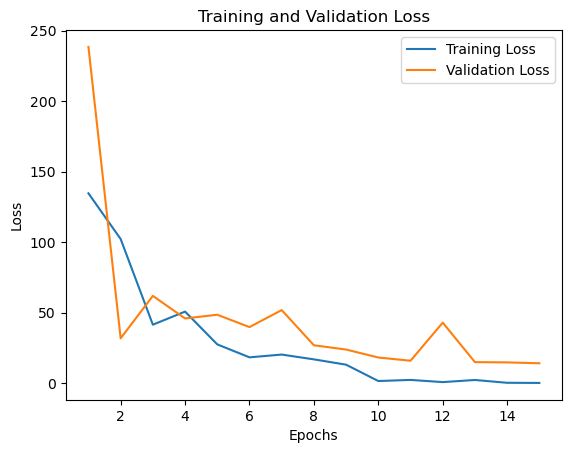

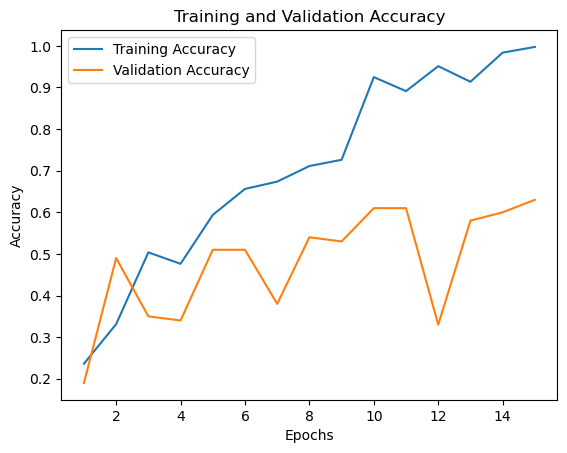

In [13]:
## Your Code ------------ Still To DO ---------------
epochs = np.array(range(1, 16))

plt.plot(epochs, history.history["loss"], label="Training Loss")
plt.plot(epochs, history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

plt.plot(epochs, history.history["accuracy"], label="Training Accuracy")
plt.plot(epochs, history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

## Task 8
Experiment with 3 different orders of magnitude for the learning rate. Plot the results and discuss in the below markdown cell

In [14]:
## Your code
trained_model_low_lr, history_low_lr = transfer_learning(train_set, eval_set, model, (0.001, 0.0, False))
trained_model_high_lr, history_high_lr = transfer_learning(train_set, eval_set, model, (0.1, 0.0, False))

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 208ms/step - accuracy: 0.2050 - loss: 14.0914 - val_accuracy: 0.2400 - val_loss: 11.3346
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.3187 - loss: 9.5037 - val_accuracy: 0.4200 - val_loss: 7.7373
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.4437 - loss: 5.7617 - val_accuracy: 0.6100 - val_loss: 2.2359
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.5638 - loss: 2.5465 - val_accuracy: 0.5200 - val_loss: 3.5610
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.5775 - loss: 3.5252 - val_accuracy: 0.4200 - val_loss: 4.8502
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.6600 - loss: 2.2074 - val_accuracy: 0.3200 - val_loss: 7.8186
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.7250 - loss: 1.6844 - val_accuracy: 0.4600 - val_loss: 2.5965
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - accuracy: 0.7638 - loss: 1.2333 - val_accuracy: 

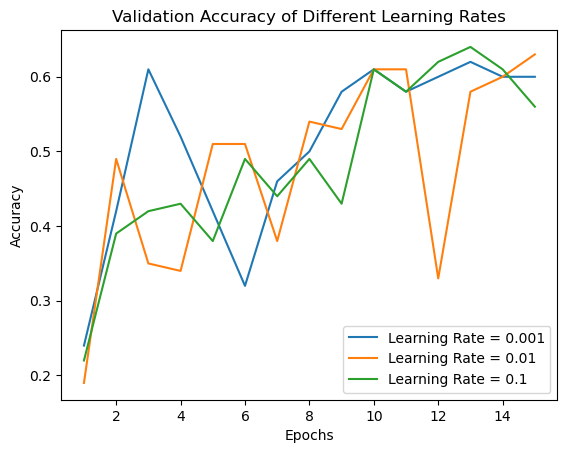

In [15]:
plt.plot(epochs, history_low_lr.history["val_accuracy"], label="Learning Rate = 0.001")
plt.plot(epochs, history.history["val_accuracy"], label="Learning Rate = 0.01")
plt.plot(epochs, history_high_lr.history["val_accuracy"], label="Learning Rate = 0.1")
plt.legend()
plt.title("Validation Accuracy of Different Learning Rates")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

### Task 8 Analysis and discussion


## Task 9
Run the resulting classifier on your test dataset using results from the best learning rate you experimented with. Compute and display the confusion matrix. 

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 299ms/step


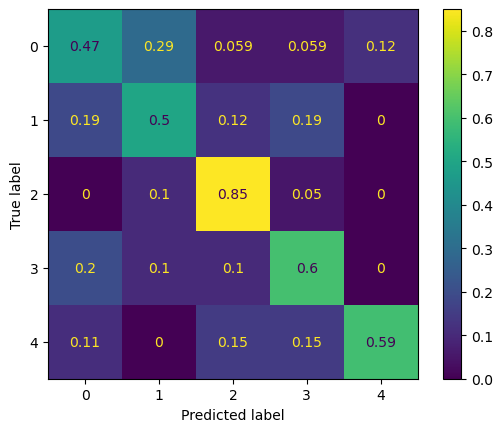

In [16]:
## Your code
predictions = trained_model_low_lr.predict(test_set[0]).argmax(axis=1)
test_set_labels = test_set[1].argmax(axis=1)
cm = confusion_matrix(test_set_labels, predictions, normalize="true")
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()


## Task 10
Compute the precision, recall, and f1 scores of your classifier on the test dataset using the best learning rate. Report on the results and comment. 

In [17]:
## Your code
precision = precision_score(test_set_labels, predictions, average="weighted")
recall = recall_score(test_set_labels, predictions, average="weighted")
f1 = f1_score(test_set_labels, predictions, average="weighted")

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


Precision: 0.6359046182575594
Recall: 0.61
F1 Score: 0.6121893009782724


### Task 10 Analysis and discussion

## Task 11
Perform k-fold validation on the dataset with k = 3. 

In [18]:
def k_fold_validation(features, ground_truth, classifier, k=2):
    '''
    Inputs:
        - features: np.ndarray of features in the dataset
        - ground_truth: np.ndarray of class values associated with the features
        - fit_func: f
        - classifier: class object with both fit() and predict() methods which
        can be applied to subsets of the features and ground_truth inputs.
        - predict_func: function, calling predict_func(features) should return
        a numpy array of class predictions which can in turn be input to the 
        functions in this script to calculate performance metrics.
        - k: int, number of sub-sets to partition the data into. default is k=2
    Outputs:
        - avg_metrics: np.ndarray of shape (3, c) where c is the number of classes.
        The first row is the average precision for each class over the k
        validation steps. Second row is recall and third row is f1 score.
        - sigma_metrics: np.ndarray, each value is the standard deviation of 
        the performance metrics [precision, recall, f1_score]
    '''
    
    #split data
    
    feature_folds = np.array_split(features, k)
    class_folds = np.array_split(ground_truth, k)
    
    metrics = np.zeros([3,3])
    
    #go through each partition and use it as a test set.
    for partition_no in range(k):
        #determine test and train sets
        X_test = feature_folds[partition_no]
        Y_test = class_folds[partition_no]
        
        #print(X_test.shape)
        #print(Y_test.shape)

        # Training folds
        X_train = np.concatenate([feature_folds[i] for i in range(k) if i != partition_no], axis=0)
        Y_train = np.concatenate([class_folds[i] for i in range(k) if i != partition_no], axis=0)
        
        #print(X_train.shape)
        #print(Y_train.shape)

        classifier.fit(X_train, Y_train)
        predictions = classifier.predict(X_test)

        y_true = np.argmax(Y_test, axis=1)
        y_pred = np.argmax(predictions, axis=1)

        
        #calculate performance metrics
        precision = precision_score(y_true, y_pred, average="weighted")
        recall = recall_score(y_true, y_pred, average="weighted")
        f1 = f1_score(y_true, y_pred, average="weighted")

        metrics[partition_no, 0] = precision
        metrics[partition_no, 1] = recall
        metrics[partition_no, 2] = f1

        #print(f"Precision: {precision}")
        #print(f"Recall: {recall}")
        #print(f"F1 Score: {f1}")
    
    #perform statistical analyses on metrics
    avg_metrics = np.mean(metrics, axis=0)
    sigma_metrics = np.std(metrics, axis=0)

    return avg_metrics, sigma_metrics

In [19]:
## Your code
# xx = k_fold_validation(xx, xx, xx, xx)
avg_metrics, sigma_metrics = k_fold_validation(X, Y, trained_model_low_lr, k=3)

print("Average Metrics")
print(f"Precision: {avg_metrics[0]:.4f}")
print(f"Recall:    {avg_metrics[1]:.4f}")
print(f"F1 Score:  {avg_metrics[2]:.4f}\n")

print("Standard Deviation")
print(f"Precision SD: {sigma_metrics[0]:.4f}")
print(f"Recall SD:    {sigma_metrics[1]:.4f}")
print(f"F1 SD:        {sigma_metrics[2]:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - accuracy: 0.7177 - loss: 1.5725
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 194ms/step - accuracy: 0.8306 - loss: 0.6568
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.8261 - loss: 0.7236
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step
Average Metrics
Precision: 0.8871
Recall:    0.8481
F1 Score:  0.8256

Standard Deviation
Precision SD: 0.0663
Recall SD:    0.0997
F1 SD:        0.1320


Comment on the results and any differences with the previous test-train split. 
Repeat with two different values for k and comment on the results. 

### Comments and analysis

## Task 12
With the best learning rate that you found in the previous task, add a non-zero momentum to the training with the SGD optimizer (consider 3 values for the momentum). Report on how your results change.  

In [20]:
## Code
trained_model_momentum, history_momentum = transfer_learning(train_set, eval_set, model, (0.01, 0.67, False))

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 245ms/step - accuracy: 0.2650 - loss: 178.5555 - val_accuracy: 0.4300 - val_loss: 52.7413
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step - accuracy: 0.3812 - loss: 89.7875 - val_accuracy: 0.2900 - val_loss: 129.2450
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step - accuracy: 0.6237 - loss: 33.7362 - val_accuracy: 0.5100 - val_loss: 32.1521
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step - accuracy: 0.7800 - loss: 9.7524 - val_accuracy: 0.3600 - val_loss: 57.2051
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - accuracy: 0.8400 - loss: 6.3708 - val_accuracy: 0.5100 - val_loss: 33.9328
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 207ms/step - accuracy: 0.9075 - loss: 3.2549 - val_accuracy: 0.4900 - val_loss: 37.7843
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - accuracy: 0.9087 - loss: 2.1752 - val_accuracy: 0.6000 - val_loss: 26.6503
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - accuracy: 0.8863 - loss: 3.8999 - val_

### Report

## Task 13
Now using “accelerated transfer learning”, repeat the training process (k-fold validation is optional this time). You should prepare your training, validation and test sets based on {(F(x1).t1), (F(x2),t2),...,(F(xm),tm)}, and re-do Task 12. 


In [24]:
def accelerated_learning(train_set, eval_set, model, parameters):
    '''
    Implement and perform accelerated transfer learning here.

    Inputs:
        - train_set: list or tuple of the training images and labels in the
            form (images, labels) for training the classifier
        - eval_set: list or tuple of the images and labels used in evaluating
            the model during training, in the form (images, labels)
        - model: an instance of tf.keras.applications.MobileNetV2
        - parameters: list or tuple of parameters to use during training:
            (learning_rate, momentum, nesterov)


    Outputs:
        - model : an instance of tf.keras.applications.MobileNetV2

    '''
    # Feature extractor (everything except final Dense layer)
    feature_extractor = keras.Model(inputs=model.input,outputs=model.layers[-2].output)

    train_features = feature_extractor.predict(train_set[0], verbose=0)
    eval_features = feature_extractor.predict(eval_set[0], verbose=0)

    # Build classifier operating on extracted features
    classifier = keras.Sequential([keras.layers.Input(shape=train_features.shape[1:]), keras.layers.Dense(5, activation="softmax")])

    classifier.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.SGD(learning_rate=parameters[0], momentum=parameters[1], nesterov=parameters[2]), 
                       metrics=["accuracy"])

    history = classifier.fit(train_features, train_set[1], validation_data=(eval_features, eval_set[1]), epochs=15)

    return classifier, history


Plot and comment on the results and differences against the standard implementation of transfer learning. 

In [26]:
## Code
trained_model_accel, history_accel = accelerated_learning(train_set, eval_set, model, (0.01, 0.67, False))

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2375 - loss: 224.9054 - val_accuracy: 0.2100 - val_loss: 186.3095
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4325 - loss: 79.3424 - val_accuracy: 0.3800 - val_loss: 72.1706
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5900 - loss: 40.0125 - val_accuracy: 0.5200 - val_loss: 38.2469
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7325 - loss: 14.2549 - val_accuracy: 0.4400 - val_loss: 43.7635
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8313 - loss: 6.4854 - val_accuracy: 0.5000 - val_loss: 32.0378
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8863 - loss: 3.9433 - val_accuracy: 0.5600 - val_loss: 26.5536
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9250 - loss: 2.3706 - val_accuracy: 0.5400 - val_loss: 27.4647
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9087 - loss: 2.1468 - val_accuracy: 0.520

### Your Comments:

## Task 14
Use the results of all experiments to make suggestions for future work and recommendations for parameter values to anyone else who may be interested in a similar implementation of transfer learning. 

### Your answer: